In [1]:
import sys
import os

print("Current Working Directory:", os.getcwd())

Current Working Directory: /Users/anjansuputra/Documents/GitHub/Emasters_Group-2_CapstoneProject


In [2]:
from pathlib import Path
import json
import re
import gc
import yaml
import pickle
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

os.environ["TOKENIZERS_PARALLELISM"] = "false"

from src.data.data_loader import DatasetLoader
from src.models.load_model import ModelLoader
from src.generators.program_generator import GenerationPipeline
from src.generators.doc_gen import DocGenerator
from src.generators.text_to_sql import TextToSQLGenerator
from src.evaluation.metrics import EvaluationMetrics
from src.evaluation.comparator import ModelComparator
from src.evaluation.visualization import ResultVisualizer

import torch

print("✅ Imports ready.")

/Users/anjansuputra/miniforge3/envs/ApexEnv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Imports ready.


## 1. Configuration

In [3]:
class DictToObject:
    def __init__(self, data: dict):
        for key, value in data.items():
            if isinstance(value, dict):
                setattr(self, key, DictToObject(value))
            else:
                setattr(self, key, value)


def load_config(yaml_path: str = "configs/config.yaml") -> DictToObject:
    path = Path(yaml_path)
    if not path.exists():
        raise FileNotFoundError(f"Config file not found at: {path.resolve()}")
    with open(path, "r", encoding="utf-8") as f:
        config_dict = yaml.safe_load(f) or {}
    return DictToObject(config_dict)


config = load_config("configs/config.yaml")
print(f"Base Model: {config.model_name}")
print(f"Data Directory: {config.data_paths.raw_dir}")

Base Model: Qwen/Qwen2.5-Coder-0.5B-Instruct
Data Directory: data/raw


## 2. Load Evaluation Datasets

We evaluate on the two generation tasks requested:

- **Text-to-SQL** → `data/processed/spider_eval.jsonl` (Spider benchmark, question/gold-SQL/schema/db_id)
- **Documentation Generation** → `data/processed/doc_generation.jsonl` (code / reference docstring pairs)


In [4]:
def load_jsonl(path):
    items = []
    p = Path(path)
    if not p.exists():
        print(f"⚠️ File not found: {p}")
        return items
    with open(p, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                items.append(json.loads(line))
    return items


# --- Text-to-SQL evaluation set -------------------------------------------------
N_SQL_SAMPLES = 100  # keep the notebook fast; increase for a fuller evaluation

sql_eval_data = load_jsonl("data/processed/spider_eval.jsonl")
sql_eval_samples = sql_eval_data[:N_SQL_SAMPLES] if sql_eval_data else []
print(f"Loaded {len(sql_eval_data)} Text-to-SQL records — using {len(sql_eval_samples)} for this run.")

# --- Documentation Generation evaluation set ------------------------------------
doc_eval_samples = load_jsonl("data/processed/doc_generation.jsonl")
print(f"Loaded {len(doc_eval_samples)} Documentation Generation records.")

Loaded 1034 Text-to-SQL records — using 100 for this run.
Loaded 3 Documentation Generation records.


## 3. Load / Fine-Tune the LoRA-Adapted Model

This notebook loads the **base model** and then attaches a **LoRA adapter**. If a previously
trained adapter already exists at `config.lora.output_dir`, it is loaded directly (fast path).
Otherwise, a short LoRA fine-tuning run is performed on the processed task files
(`program_generation.jsonl`, `doc_generation.jsonl`, `commit_generation.jsonl`), mirroring the
fine-tuning step in `main.ipynb`.

In [5]:
model_loader = ModelLoader(config)
tokenizer = model_loader.load_tokenizer()
base_model = model_loader.load_base_model()

lora_checkpoint_dir = Path(config.lora.output_dir)
adapter_config_path = lora_checkpoint_dir / "adapter_config.json"
adapter_ready = adapter_config_path.exists()

if adapter_ready:
    try:
        with open(adapter_config_path, "r", encoding="utf-8") as f:
            json.load(f)
    except (json.JSONDecodeError, OSError) as exc:
        print(f"⚠️ Found {adapter_config_path} but it failed to parse ({exc}). "
              f"Treating it as corrupted and retraining instead.")
        adapter_ready = False

lora_model = None
if adapter_ready:
    print(f"✅ Found existing LoRA adapter at: {lora_checkpoint_dir}")
    try:
        lora_model = model_loader.load_lora_model(str(lora_checkpoint_dir))
    except Exception as exc:
        print(f"⚠️ Failed to load existing LoRA adapter ({exc}). "
              f"Falling back to a fresh fine-tuning pass...")
        lora_model = None

if lora_model is None:
    print("⚠️ No usable LoRA adapter found — running a short fine-tuning pass...")

    lora_model = model_loader.setup_lora_training(
        base_model,
        r=config.lora.r,
        alpha=config.lora.alpha,
    )

    def _load_jsonl(path):
        items = []
        p = Path(path)
        if not p.exists():
            return items
        with open(p, "r", encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if line:
                    items.append(json.loads(line))
        return items

    def _completion_prompt(instruction):
        return f"User Question: {instruction}\n\nAnswer: "

    train_texts = []
    for item in _load_jsonl("data/processed/program_generation.jsonl"):
        instr, out = item.get("instruction") or item.get("prompt", ""), item.get("code", "")
        if instr and out:
            train_texts.append((_completion_prompt(instr), out))
    for item in _load_jsonl("data/processed/doc_generation.jsonl"):
        instr = item.get("instruction") or item.get("prompt", "") or item.get("code", "")
        out = item.get("docstring") or item.get("output", "")
        if instr and out:
            train_texts.append((_completion_prompt(instr), out))
    for item in _load_jsonl("data/processed/commit_generation.jsonl"):
        instr = item.get("instruction") or item.get("prompt", "") or item.get("diff", "")
        out = item.get("commit_message") or item.get("output", "")
        if instr and out:
            train_texts.append((_completion_prompt(instr), out))

    print(f"Prepared {len(train_texts)} training examples for LoRA fine-tuning.")

    lora_model = model_loader.train_lora(
        lora_model,
        tokenizer,
        train_texts,
        epochs=3,
        batch_size=1,
        grad_accum_steps=4,
        learning_rate=1e-4,
        max_length=256,
    )

    if lora_checkpoint_dir.exists():
        shutil.rmtree(lora_checkpoint_dir, ignore_errors=True)
    lora_checkpoint_dir.mkdir(parents=True, exist_ok=True)

    try:
        lora_model.save_pretrained(str(lora_checkpoint_dir))
    except Exception as exc:
        print(f"⚠️ save_pretrained hit an unexpected issue ({exc}). "
              f"Retrying once after clearing the checkpoint directory again...")
        shutil.rmtree(lora_checkpoint_dir, ignore_errors=True)
        lora_checkpoint_dir.mkdir(parents=True, exist_ok=True)
        lora_model.save_pretrained(str(lora_checkpoint_dir))

    tokenizer.save_pretrained(str(lora_checkpoint_dir))
    print(f"✅ LoRA fine-tuned adapter saved to: {lora_checkpoint_dir}")

finetuned_pipeline = GenerationPipeline(lora_model, tokenizer, config.generation)
print("✅ Fine-tuned (LoRA) model loaded and ready for generation.")

`torch_dtype` is deprecated! Use `dtype` instead!


✅ Found existing LoRA adapter at: models/checkpoints/lora_finetuned
✅ Fine-tuned (LoRA) model loaded and ready for generation.


## 4. Task 1 — Text-to-SQL Generation (Fine-Tuned Model)

In [6]:
def clean_sql_prediction(pred_sql: str) -> str:
    if not pred_sql:
        return ""

    # Remove everything after common JSON leakage patterns
    json_patterns = [
        '", "mongodb',
        '", "',
        '", "collection',
        '", "operation',
        '", "filter',
        '": {',
        '": "',
    ]

    for pattern in json_patterns:
        if pattern in pred_sql:
            pred_sql = pred_sql.split(pattern)[0]

    # Strip trailing whitespace, quotes, commas, braces
    pred_sql = pred_sql.rstrip()
    pred_sql = pred_sql.rstrip('",}')
    pred_sql = pred_sql.rstrip()

    # Check for incomplete SQL (missing closing parentheses)
    open_parens = pred_sql.count('(')
    close_parens = pred_sql.count(')')

    if open_parens > close_parens:
        # Add missing closing parentheses
        pred_sql += ')' * (open_parens - close_parens)

    # Remove trailing semicolons for consistency
    pred_sql = pred_sql.rstrip(';').strip()

    return pred_sql

text_to_sql_gen = TextToSQLGenerator(pipeline=finetuned_pipeline)

questions, gold_sqls, pred_sqls, db_ids, schemas = [], [], [], [], []

print(f"Generating SQL for {len(sql_eval_samples)} samples using the Fine-Tuned Model...")

for idx, item in enumerate(sql_eval_samples):
    question = item.get("question", "")
    schema = item.get("schema", "N/A")
    gold_sql = item.get("gold_sql", "")
    db_id = item.get("db_id", "")

    if not question:
        continue

    result = text_to_sql_gen.generate_queries(question=question, schema=schema, dialect="sqlite")
    pred_sql = result.get("sql_query", "")

    # Apply comprehensive SQL cleaning
    pred_sql = clean_sql_prediction(pred_sql)

    questions.append(question)
    gold_sqls.append(gold_sql)
    pred_sqls.append(pred_sql)
    db_ids.append(db_id)
    schemas.append(schema)

    print(f"[{idx + 1}/{len(sql_eval_samples)}] Q: {question[:70]}")
    print(f"    Gold: {gold_sql[:80]}")
    print(f"    Pred: {pred_sql[:80]}\n")

sql_results_df = pd.DataFrame({
    "question": questions,
    "db_id": db_ids,
    "gold_sql": gold_sqls,
    "predicted_sql": pred_sqls,
})
sql_results_df.head(10)

Generating SQL for 100 samples using the Fine-Tuned Model...


/Users/anjansuputra/miniforge3/envs/ApexEnv/lib/python3.11/site-packages/transformers/pytorch_utils.py:339: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  test_elements = torch.tensor(test_elements)


[1/100] Q: How many singers do we have?
    Gold: SELECT count(*) FROM singer
    Pred: SELECT count(*) FROM stadium

[2/100] Q: What is the total number of singers?
    Gold: SELECT count(*) FROM singer
    Pred: SELECT count(*) FROM singer

[3/100] Q: Show name, country, age for all singers ordered by age from the oldest
    Gold: SELECT name ,  country ,  age FROM singer ORDER BY age DESC
    Pred: SELECT name, country, age FROM singer ORDER BY age DESC

[4/100] Q: What are the names, countries, and ages for every singer in descending
    Gold: SELECT name ,  country ,  age FROM singer ORDER BY age DESC
    Pred: SELECT name, country, age FROM singer ORDER BY age DESC

[5/100] Q: What is the average, minimum, and maximum age of all singers from Fran
    Gold: SELECT avg(age) ,  min(age) ,  max(age) FROM singer WHERE country  =  'France'
    Pred: SELECT AVG(age) FROM singer WHERE country = 'France'

[6/100] Q: What is the average, minimum, and maximum age for all French singers?
   

,question,db_id,gold_sql,predicted_sql
0,How many singers do we have?,concert_singer,SELECT count(*) FROM singer,SELECT count(*) FROM stadium
1,What is the total number of singers?,concert_singer,SELECT count(*) FROM singer,SELECT count(*) FROM singer
2,"Show name, country, age for all singers ordere...",concert_singer,"SELECT name , country , age FROM singer ORDE...","SELECT name, country, age FROM singer ORDER BY..."
3,"What are the names, countries, and ages for ev...",concert_singer,"SELECT name , country , age FROM singer ORDE...","SELECT name, country, age FROM singer ORDER BY..."
4,"What is the average, minimum, and maximum age ...",concert_singer,"SELECT avg(age) , min(age) , max(age) FROM s...",SELECT AVG(age) FROM singer WHERE country = 'F...
5,"What is the average, minimum, and maximum age ...",concert_singer,"SELECT avg(age) , min(age) , max(age) FROM s...",SELECT AVG(age) FROM singer WHERE country = 'F...
6,Show the name and the release year of the song...,concert_singer,"SELECT song_name , song_release_year FROM sin...",SELECT * FROM singer WHERE Age = ( SELECT MIN(...
7,What are the names and release years for all t...,concert_singer,"SELECT song_name , song_release_year FROM sin...",SELECT * FROM singer WHERE Age = 25
8,What are all distinct countries where singers ...,concert_singer,SELECT DISTINCT country FROM singer WHERE age ...,SELECT DISTINCT country FROM singer WHERE age ...
9,What are the different countries with singers...,concert_singer,SELECT DISTINCT country FROM singer WHERE age ...,SELECT DISTINCT country FROM singer WHERE age ...


### 4.1 Text-to-SQL Metrics (Fine-Tuned Model)

In [7]:
def normalize_sql(sql: str) -> str:
    return re.sub(r"\s+", " ", (sql or "").strip().lower()).rstrip(";").strip()

exact_matches = sum(
    1 for g, p in zip(gold_sqls, pred_sqls) if normalize_sql(g) == normalize_sql(p)
)
exact_match_acc = exact_matches / len(gold_sqls) if gold_sqls else 0.0

bleu_score = EvaluationMetrics.compute_bleu(gold_sqls, pred_sqls)
codebert_score = EvaluationMetrics.compute_bertscore(gold_sqls, pred_sqls, device="cpu")
f1_score = EvaluationMetrics.compute_f1(gold_sqls, pred_sqls)
rouge_scores = EvaluationMetrics.compute_rouge(gold_sqls, pred_sqls)

db_paths = [
    str(Path("data/raw/Spider/spider_data/database") / db_id / f"{db_id}.sqlite")
    for db_id in db_ids
]
missing_dbs = sum(1 for p in db_paths if not Path(p).exists())
if missing_dbs:
    print(f"⚠️ {missing_dbs}/{len(db_paths)} Spider SQLite databases were not found locally — "
          f"place the Spider `database/` folder under data/raw/Spider/spider_data/ for a fully "
          f"populated Execution Accuracy score.")

execution_accuracy = EvaluationMetrics.compute_sql_execution_accuracy(gold_sqls, pred_sqls, db_paths)

sql_metrics_finetuned = {
    "BLEU": round(bleu_score, 4),
    "CodeBERTScore": round(codebert_score, 4),
    "F1_Score": round(f1_score, 4),
    "ROUGE-1": round(rouge_scores["ROUGE-1"], 4),
    "ROUGE-L": round(rouge_scores["ROUGE-L"], 4),
    "Exact_Match": round(exact_match_acc, 4),
    "Execution_Accuracy": round(execution_accuracy, 4),
}

print(f"\n✅ Text-to-SQL Metrics — Fine-Tuned Model:")
for k, v in sql_metrics_finetuned.items():
    print(f"   {k:20s}: {v}")

SQL execution failed for DB data/raw/Spider/spider_data/database/concert_singer/concert_singer.sqlite: no such column: Average_number
SQL execution failed for DB data/raw/Spider/spider_data/database/concert_singer/concert_singer.sqlite: no such column: Average_number
SQL execution failed for DB data/raw/Spider/spider_data/database/concert_singer/concert_singer.sqlite: no such column: stadium_name
SQL execution failed for DB data/raw/Spider/spider_data/database/concert_singer/concert_singer.sqlite: near ")": syntax error
SQL execution failed for DB data/raw/Spider/spider_data/database/concert_singer/concert_singer.sqlite: near ")": syntax error
SQL execution failed for DB data/raw/Spider/spider_data/database/concert_singer/concert_singer.sqlite: no such table: concerts
SQL execution failed for DB data/raw/Spider/spider_data/database/concert_singer/concert_singer.sqlite: no such table: singer_in
SQL execution failed for DB data/raw/Spider/spider_data/database/concert_singer/concert_singe


✅ Text-to-SQL Metrics — Fine-Tuned Model:
   BLEU                : 0.2467
   CodeBERTScore       : 0.9759
   F1_Score            : 0.4879
   ROUGE-1             : 0.4602
   ROUGE-L             : 0.4503
   Exact_Match         : 0.08
   Execution_Accuracy  : 0.14


### 4.2 Text-to-SQL Visualization (Fine-Tuned Model)

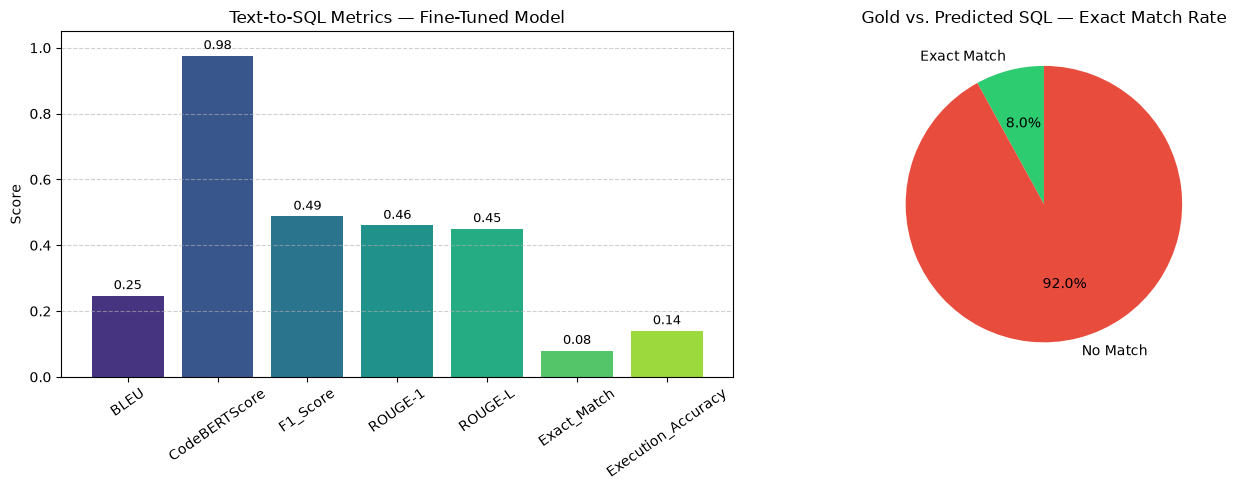

,question,db_id,gold_sql,predicted_sql,exact_match
0,How many singers do we have?,concert_singer,SELECT count(*) FROM singer,SELECT count(*) FROM stadium,False
1,What is the total number of singers?,concert_singer,SELECT count(*) FROM singer,SELECT count(*) FROM singer,True
2,"Show name, country, age for all singers ordered by age from the oldest to the youngest.",concert_singer,"SELECT name , country , age FROM singer ORDER BY age DESC","SELECT name, country, age FROM singer ORDER BY age DESC",False
3,"What are the names, countries, and ages for every singer in descending order of age?",concert_singer,"SELECT name , country , age FROM singer ORDER BY age DESC","SELECT name, country, age FROM singer ORDER BY age DESC",False
4,"What is the average, minimum, and maximum age of all singers from France?",concert_singer,"SELECT avg(age) , min(age) , max(age) FROM singer WHERE country = 'France'",SELECT AVG(age) FROM singer WHERE country = 'France',False
5,"What is the average, minimum, and maximum age for all French singers?",concert_singer,"SELECT avg(age) , min(age) , max(age) FROM singer WHERE country = 'France'",SELECT AVG(age) FROM singer WHERE country = 'France',False
6,Show the name and the release year of the song by the youngest singer.,concert_singer,"SELECT song_name , song_release_year FROM singer ORDER BY age LIMIT 1",SELECT * FROM singer WHERE Age = ( SELECT MIN(Age) FROM singer),False
7,What are the names and release years for all the songs of the youngest singer?,concert_singer,"SELECT song_name , song_release_year FROM singer ORDER BY age LIMIT 1",SELECT * FROM singer WHERE Age = 25,False
8,What are all distinct countries where singers above age 20 are from?,concert_singer,SELECT DISTINCT country FROM singer WHERE age > 20,SELECT DISTINCT country FROM singer WHERE age > 20,True
9,What are the different countries with singers above age 20?,concert_singer,SELECT DISTINCT country FROM singer WHERE age > 20,SELECT DISTINCT country FROM singer WHERE age > 20,True


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Metric scores bar chart ---
metric_names = list(sql_metrics_finetuned.keys())
metric_values = list(sql_metrics_finetuned.values())
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(metric_names)))

axes[0].bar(metric_names, metric_values, color=colors)
axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel("Score")
axes[0].set_title(f"Text-to-SQL Metrics — Fine-Tuned Model")
axes[0].tick_params(axis="x", rotation=35)
axes[0].grid(axis="y", linestyle="--", alpha=0.6)
for i, v in enumerate(metric_values):
    axes[0].text(i, v + 0.02, f"{v:.2f}", ha="center", fontsize=9)

# --- Exact match distribution ---
match_labels = ["Exact Match", "No Match"]
match_counts = [exact_matches, len(gold_sqls) - exact_matches]
axes[1].pie(
    match_counts, labels=match_labels, autopct="%1.1f%%",
    colors=["#2ecc71", "#e74c3c"], startangle=90,
)
axes[1].set_title("Gold vs. Predicted SQL — Exact Match Rate")

plt.tight_layout()
plt.savefig(f"src/plots/text_to_sql_finetuned_metrics.png", bbox_inches="tight")
plt.show()

# --- Qualitative sample viewer ---
sample_view = sql_results_df.copy()
sample_view["exact_match"] = [normalize_sql(g) == normalize_sql(p) for g, p in zip(gold_sqls, pred_sqls)]

def _highlight_match(row):
    color = "background-color: #d4f7dc" if row["exact_match"] else "background-color: #fbe0df"
    return [color] * len(row)

sample_view.head(10).style.apply(_highlight_match, axis=1)

## 5. Task 2 — Documentation Generation (Fine-Tuned Model)

In [9]:
doc_gen = DocGenerator(finetuned_pipeline)

code_inputs, reference_docs, generated_docs = [], [], []

print(f"Generating docstrings for {len(doc_eval_samples)} samples using the Fine-Tuned Model...")

for idx, item in enumerate(doc_eval_samples):
    code_snippet = item.get("code", "")
    reference_doc = item.get("docstring", "")

    if not code_snippet:
        continue

    generated_doc = doc_gen.generate_docstring(code_snippet)

    code_inputs.append(code_snippet)
    reference_docs.append(reference_doc)
    generated_docs.append(generated_doc)

    print(f"[{idx + 1}/{len(doc_eval_samples)}] Code: {code_snippet[:60]}")
    print(f"    Reference : {reference_doc[:100]}")
    print(f"    Generated : {generated_doc[:100]}\n")

doc_results_df = pd.DataFrame({
    "code": code_inputs,
    "reference_docstring": reference_docs,
    "generated_docstring": generated_docs,
})
doc_results_df

Generating docstrings for 3 samples using the Fine-Tuned Model...


/Users/anjansuputra/miniforge3/envs/ApexEnv/lib/python3.11/site-packages/transformers/pytorch_utils.py:339: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  test_elements = torch.tensor(test_elements)


[1/3] Code: def add(a, b):
    return a + b
    Reference : Adds two numbers and returns the result.
    Generated : This function takes two parameters, `a` and `b`, and returns their sum. It's designed to be simple a

[2/3] Code: def multiply(a, b):
    return a * b
    Reference : Multiplies two numbers and returns the result.
    Generated : This function takes two numbers as input and returns their product. It is designed to be efficient a

[3/3] Code: def is_positive(number):
    return number > 0
    Reference : Checks whether the given number is positive.
    Generated : This function checks if a given number is positive. It returns True if the number is greater than ze



,code,reference_docstring,generated_docstring
0,"def add(a, b):\n return a + b",Adds two numbers and returns the result.,"This function takes two parameters, `a` and `b..."
1,"def multiply(a, b):\n return a * b",Multiplies two numbers and returns the result.,This function takes two numbers as input and r...
2,def is_positive(number):\n return number > 0,Checks whether the given number is positive.,This function checks if a given number is posi...


### 5.1 Documentation Generation Metrics (Fine-Tuned Model)

In [10]:
doc_bleu = EvaluationMetrics.compute_bleu(reference_docs, generated_docs)
doc_codebert = EvaluationMetrics.compute_bertscore(reference_docs, generated_docs, device="cpu")
doc_f1 = EvaluationMetrics.compute_f1(reference_docs, generated_docs)
doc_rouge = EvaluationMetrics.compute_rouge(reference_docs, generated_docs)

doc_metrics_finetuned = {
    "BLEU": round(doc_bleu, 4),
    "CodeBERTScore": round(doc_codebert, 4),
    "F1_Score": round(doc_f1, 4),
    "ROUGE-1": round(doc_rouge["ROUGE-1"], 4),
    "ROUGE-L": round(doc_rouge["ROUGE-L"], 4),
    "Execution_Accuracy": None,  # N/A for free-text documentation generation
}

print(f"✅ Documentation Generation Metrics — Fine-Tuned Model:")
for k, v in doc_metrics_finetuned.items():
    print(f"   {k:20s}: {v if v is not None else 'N/A (not applicable to free text)'}")

✅ Documentation Generation Metrics — Fine-Tuned Model:
   BLEU                : 0.0528
   CodeBERTScore       : 0.9447
   F1_Score            : 0.2022
   ROUGE-1             : 0.1615
   ROUGE-L             : 0.1494
   Execution_Accuracy  : N/A (not applicable to free text)


### 5.2 Documentation Generation Visualization (Fine-Tuned Model)

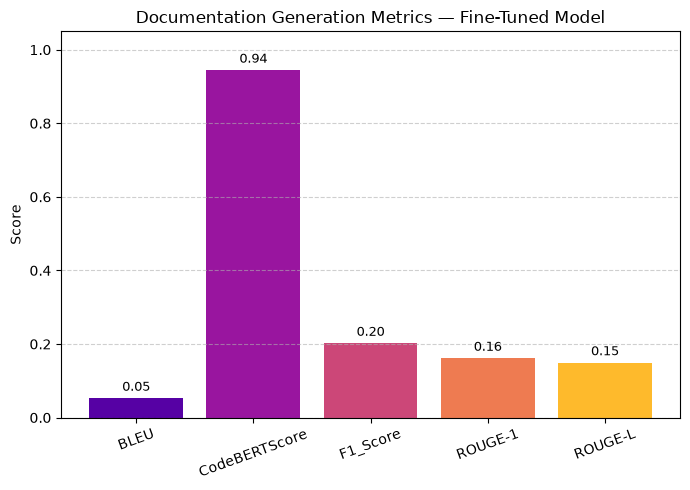

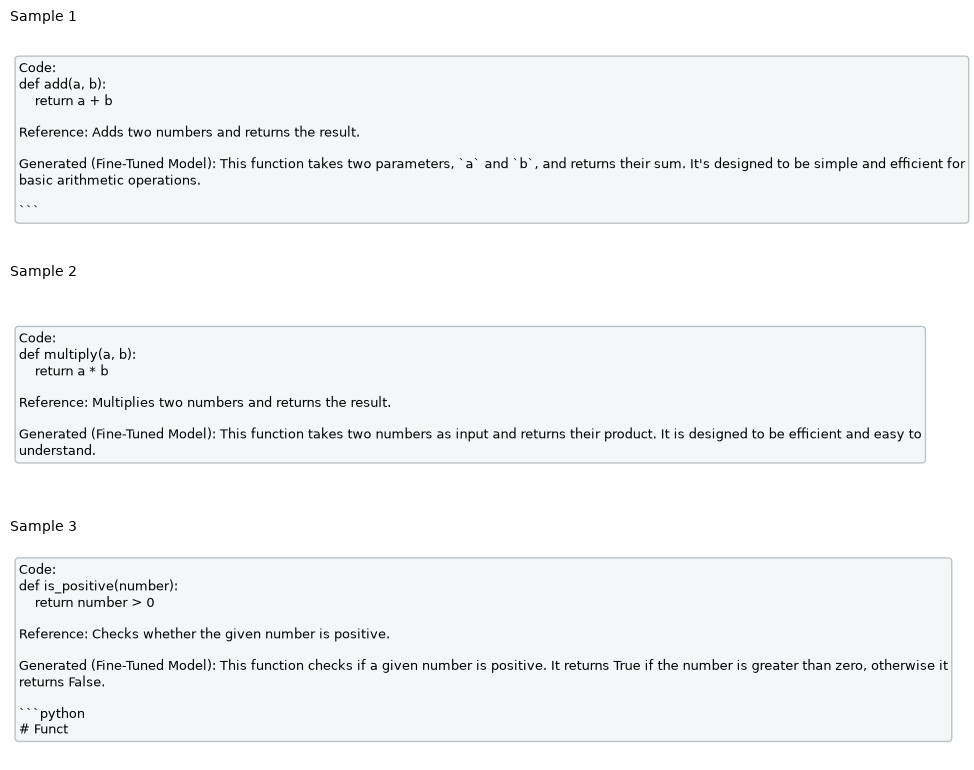

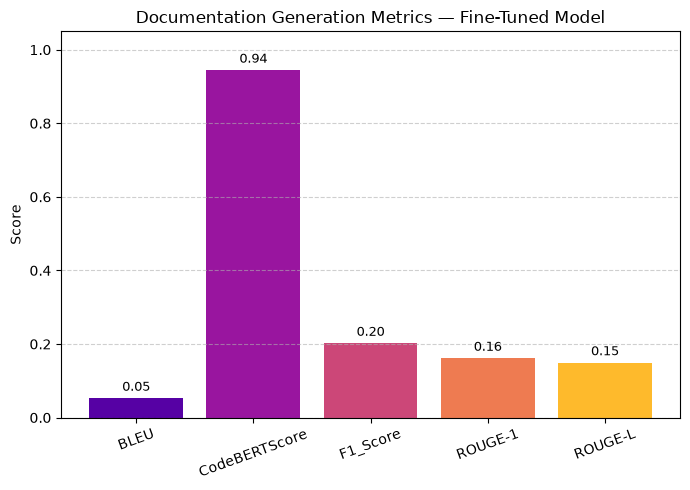

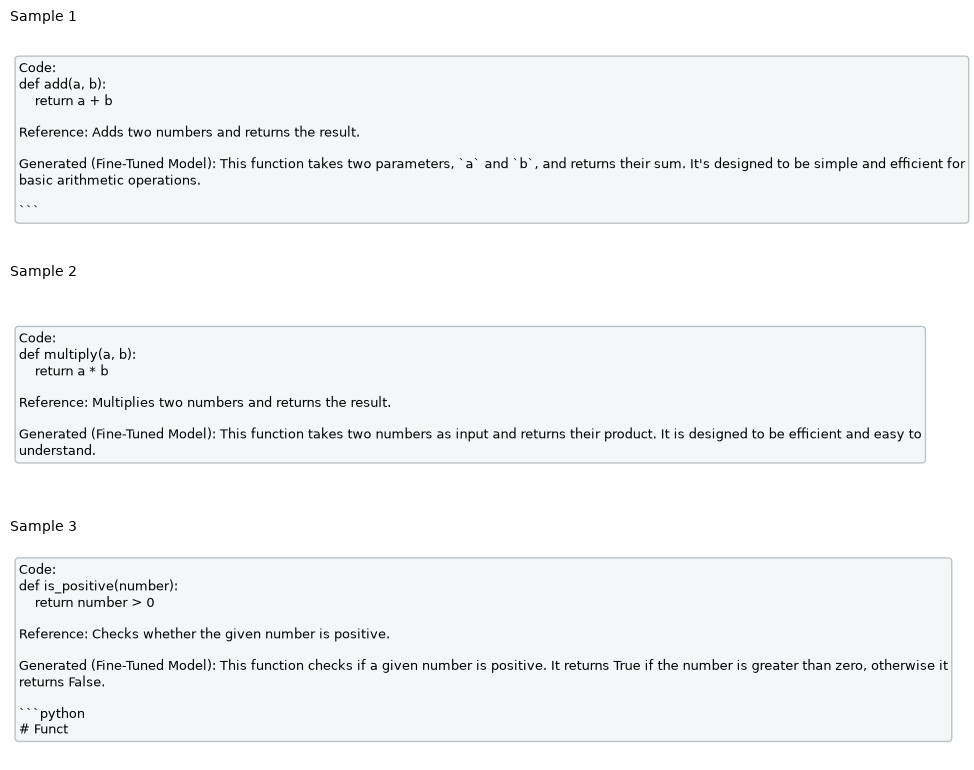

In [12]:
plot_metrics = {k: v for k, v in doc_metrics_finetuned.items() if v is not None}

fig, ax = plt.subplots(figsize=(7, 5))
colors = plt.cm.plasma(np.linspace(0.15, 0.85, len(plot_metrics)))
bars = ax.bar(list(plot_metrics.keys()), list(plot_metrics.values()), color=colors)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title(f"Documentation Generation Metrics — Fine-Tuned Model")
ax.tick_params(axis="x", rotation=20)
ax.grid(axis="y", linestyle="--", alpha=0.6)
for bar, v in zip(bars, plot_metrics.values()):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.02, f"{v:.2f}", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig(f"src/plots/doc_generation_finetuned_metrics.png", bbox_inches="tight")
plt.show()

# --- Side-by-side qualitative panel for each sample ---
n_show = len(code_inputs)
fig, axes = plt.subplots(n_show, 1, figsize=(10, 2.6 * n_show))
if n_show == 1:
    axes = [axes]

for i, ax in enumerate(axes):
    ax.axis("off")
    panel_text = (
        f"Code:\n{code_inputs[i][:150]}\n\n"
        f"Reference: {reference_docs[i][:150]}\n\n"
        f"Generated (Fine-Tuned Model): {generated_docs[i][:150]}"
    )
    ax.text(0.01, 0.5, panel_text, fontsize=9, va="center", wrap=True,
             bbox=dict(boxstyle="round", facecolor="#f4f6f7", edgecolor="#bdc3c7"))
    ax.set_title(f"Sample {i + 1}", fontsize=10, loc="left")

plt.tight_layout()
plt.savefig(f"src/plots/doc_generation_finetuned_samples.png", bbox_inches="tight")
plt.show()

## 6. Consolidated Fine-Tuned Model Results Summary

In [14]:
combined_results_finetuned = {
    "Text_to_SQL": sql_metrics_finetuned,
    "Documentation_Generation": doc_metrics_finetuned,
}

visualizer = ResultVisualizer(output_dir=config.outputs.plots_dir if hasattr(config, "outputs") else "src/plots")
visualizer.plot_comparison(
    {k: {mk: mv for mk, mv in v.items() if mv is not None} for k, v in combined_results_finetuned.items()},
    save_name="finetuned_text_to_sql_vs_doc_generation.png",
)

summary_rows = []
for task, metrics in combined_results_finetuned.items():
    for metric, value in metrics.items():
        summary_rows.append({"Task": task, "Metric": metric, "Score": value})

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

output_path = Path("outputs/generated") / "finetuned_model_results.json"
output_path.parent.mkdir(parents=True, exist_ok=True)
with open(output_path, "w", encoding="utf-8") as f:
    json.dump(combined_results_finetuned, f, indent=2)

print(f"\n✅ Fine-Tuned Model results saved to: {output_path}")

✅ Score chart saved to: output/plots/scores_finetuned_text_to_sql_vs_doc_generation.png


,Task,Metric,Score
0,Text_to_SQL,BLEU,0.2467
1,Text_to_SQL,CodeBERTScore,0.9759
2,Text_to_SQL,F1_Score,0.4879
3,Text_to_SQL,ROUGE-1,0.4602
4,Text_to_SQL,ROUGE-L,0.4503
5,Text_to_SQL,Exact_Match,0.0800
6,Text_to_SQL,Execution_Accuracy,0.1400
7,Documentation_Generation,BLEU,0.0528
8,Documentation_Generation,CodeBERTScore,0.9447
9,Documentation_Generation,F1_Score,0.2022



✅ Fine-Tuned Model results saved to: outputs/generated/finetuned_model_results.json
✅ Score chart saved to: output/plots/scores_finetuned_text_to_sql_vs_doc_generation.png


,Task,Metric,Score
0,Text_to_SQL,BLEU,0.2467
1,Text_to_SQL,CodeBERTScore,0.9759
2,Text_to_SQL,F1_Score,0.4879
3,Text_to_SQL,ROUGE-1,0.4602
4,Text_to_SQL,ROUGE-L,0.4503
5,Text_to_SQL,Exact_Match,0.0800
6,Text_to_SQL,Execution_Accuracy,0.1400
7,Documentation_Generation,BLEU,0.0528
8,Documentation_Generation,CodeBERTScore,0.9447
9,Documentation_Generation,F1_Score,0.2022



✅ Fine-Tuned Model results saved to: outputs/generated/finetuned_model_results.json


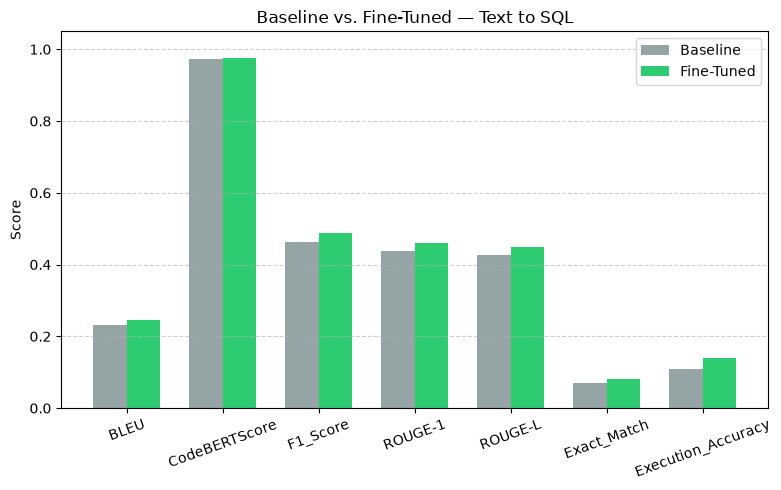

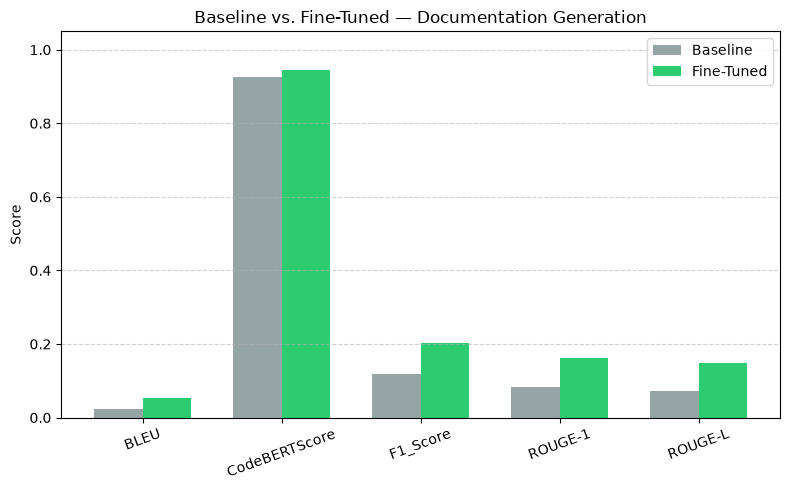

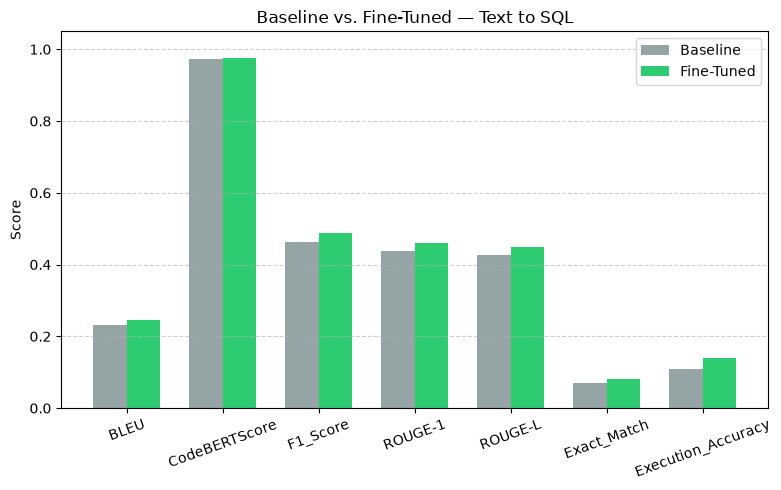

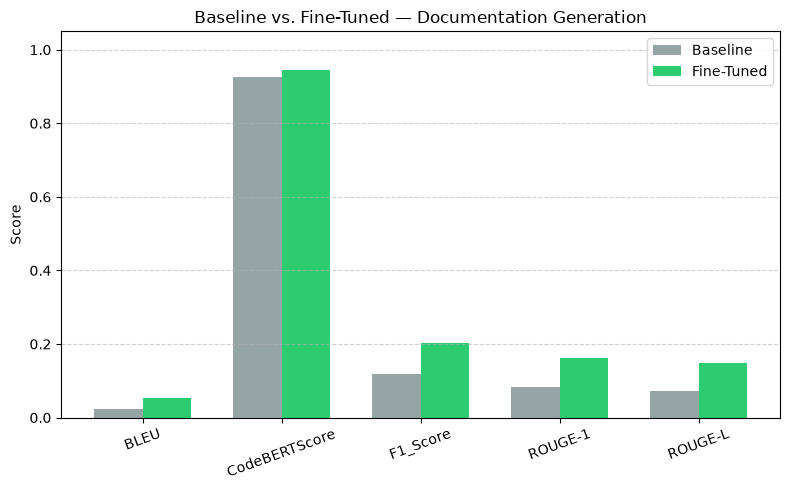

In [16]:
baseline_results_path = Path("outputs/generated/baseline_model_results.json")

if baseline_results_path.exists():
    with open(baseline_results_path, "r", encoding="utf-8") as f:
        baseline_results = json.load(f)

    for task in ["Text_to_SQL", "Documentation_Generation"]:
        base_metrics = {k: v for k, v in baseline_results.get(task, {}).items() if v is not None}
        fine_metrics = {k: v for k, v in combined_results_finetuned.get(task, {}).items() if v is not None}

        common_metrics = [m for m in fine_metrics if m in base_metrics]
        if not common_metrics:
            continue

        x = np.arange(len(common_metrics))
        width = 0.35

        fig, ax = plt.subplots(figsize=(8, 5))
        ax.bar(x - width / 2, [base_metrics[m] for m in common_metrics], width, label="Baseline", color="#95a5a6")
        ax.bar(x + width / 2, [fine_metrics[m] for m in common_metrics], width, label="Fine-Tuned", color="#2ecc71")
        ax.set_xticks(x)
        ax.set_xticklabels(common_metrics, rotation=20)
        ax.set_ylim(0, 1.05)
        ax.set_ylabel("Score")
        ax.set_title(f"Baseline vs. Fine-Tuned — {task.replace('_', ' ')}")
        ax.legend()
        ax.grid(axis="y", linestyle="--", alpha=0.6)
        plt.tight_layout()
        plt.savefig(f"src/plots/baseline_vs_finetuned_{task.lower()}.png", bbox_inches="tight")
        plt.show()
else:
    print("ℹ️ Run baseline_model.ipynb first to enable the Baseline vs. Fine-Tuned comparison.")